# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
orders = pd.read_csv ('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv ('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv ('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [3]:
# explorar datasets
orders.info()
orders.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99


In [4]:
catalog.info()
catalog.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC


In [5]:
marketing.info()
marketing.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [6]:
orders = orders.rename(columns={'fecha_hora_pedido':'fecha_pedido'})

In [7]:
#convertir formato fecha
orders['fecha_pedido']=pd.to_datetime(orders['fecha_pedido'], errors="coerce")
marketing['fecha'] = pd.to_datetime(marketing['fecha'], errors = "coerce")
orders.info()
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25100 non-null  object        
 1   id_usuario          25100 non-null  object        
 2   fecha_pedido        25100 non-null  datetime64[ns]
 3   pais                24800 non-null  object        
 4   dispositivo         25080 non-null  object        
 5   fuente_referencia   25070 non-null  object        
 6   nombre_producto     25070 non-null  object        
 7   categoria_producto  25020 non-null  object        
 8   cantidad            25050 non-null  float64       
 9   precio_unitario     25050 non-null  float64       
 10  monto_descuento     25050 non-null  float64       
 11  monto_total         25100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.3+ MB
<class 'pandas.core.frame.DataFrame'

In [8]:

#cantidad de faltantes
print(orders.isna().sum())
print()
print(orders.isna().mean()*100)


id_pedido               0
id_usuario              0
fecha_pedido            0
pais                  300
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
dtype: int64

id_pedido             0.000000
id_usuario            0.000000
fecha_pedido          0.000000
pais                  1.195219
dispositivo           0.079681
fuente_referencia     0.119522
nombre_producto       0.119522
categoria_producto    0.318725
cantidad              0.199203
precio_unitario       0.199203
monto_descuento       0.199203
monto_total           0.000000
dtype: float64


In [9]:
#coincidencia de faltantes entre fuente_referencia y nombre_producto
orders[(orders['fuente_referencia'].isna()) & (orders['nombre_producto'].notna())]

,id_pedido,id_usuario,fecha_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total


In [10]:
#coincidencia de faltantes entre cantidad y precio_unitario
orders[(orders['cantidad'].isna()) & (orders['precio_unitario'].notna())]

,id_pedido,id_usuario,fecha_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total


In [11]:
#coincidencia de faltantes entre cantidad y monto_descuento
orders[(orders['cantidad'].isna()) & (orders['monto_descuento'].notna())]

,id_pedido,id_usuario,fecha_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total


In [12]:
#coincidencia de faltantes entre precio_unitario y monto_descuento
orders[(orders['precio_unitario'].isna()) & (orders['monto_descuento'].notna())]

,id_pedido,id_usuario,fecha_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total


In [13]:
#coincidencia de faltantes entre fuente_referencia y cantidad
orders[(orders['fuente_referencia'].isna()) & (orders['cantidad'].notna())].shape

(30, 12)

In [14]:
#coincidencia de faltantes entre fuente_referencia y categoria_producto
orders[(orders['fuente_referencia'].isna()) & (orders['categoria_producto'].notna())]

,id_pedido,id_usuario,fecha_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total


In [15]:
#coincidencia de faltantes entre cantidad y categoria_producto
orders[(orders['cantidad'].isna()) & (orders['categoria_producto'].notna())]

,id_pedido,id_usuario,fecha_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total


In [16]:
orders = orders.dropna(subset=['categoria_producto'])
orders = orders.dropna(subset=['pais'])
orders = orders.dropna(subset=['dispositivo'])

In [17]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24700 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           24700 non-null  object        
 1   id_usuario          24700 non-null  object        
 2   fecha_pedido        24700 non-null  datetime64[ns]
 3   pais                24700 non-null  object        
 4   dispositivo         24700 non-null  object        
 5   fuente_referencia   24700 non-null  object        
 6   nombre_producto     24700 non-null  object        
 7   categoria_producto  24700 non-null  object        
 8   cantidad            24700 non-null  float64       
 9   precio_unitario     24700 non-null  float64       
 10  monto_descuento     24700 non-null  float64       
 11  monto_total         24700 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.4+ MB


In [18]:

#revisar variables numericas
orders.describe()


,cantidad,precio_unitario,monto_descuento,monto_total
count,24700.000000,24700.000000,24700.000000,2.470000e+04
mean,7.172632,259.318949,4.501012,2.100128e+03
std,298.368058,138.722658,5.224135,9.974774e+04
min,1.000000,20.030000,0.000000,5.240000e+00
25%,1.000000,138.617500,0.000000,1.803950e+02
50%,2.000000,258.710000,0.000000,3.416050e+02
75%,2.000000,380.297500,10.000000,5.193425e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


In [19]:
# 1. Calcula el monto teórico que DEBERÍA tener cada fila
monto_calculado = (orders['cantidad'] * orders['precio_unitario']) - orders['monto_descuento']

# 2. Encuentra las filas donde el monto real NO coincide con el calculado
# Usamos round() para evitar problemas con decimales flotantes
inconsistencias = orders[round(orders['monto_total'], 2) != round(monto_calculado, 2)].copy()

# 3. Agrega una columna para ver de cuánto es el error en dinero
inconsistencias['monto_correcto'] = monto_calculado
inconsistencias['diferencia'] = inconsistencias['monto_total'] - monto_calculado

# 4. Muestra los resultados
print(f"Se encontraron {len(inconsistencias)} filas con montos inconsistentes.")
print(inconsistencias[['cantidad', 'precio_unitario', 'monto_descuento', 'monto_total', 'monto_correcto', 'diferencia']])

Se encontraron 6165 filas con montos inconsistentes.
       cantidad  precio_unitario  monto_descuento  monto_total  \
0           2.0           332.69              0.0       665.37   
2           2.0           102.99             10.0       195.99   
6           2.0           163.59              0.0       327.19   
7           2.0           373.68              0.0       747.35   
18          2.0           180.64              5.0       356.27   
...         ...              ...              ...          ...   
25077       2.0            73.20              0.0       146.41   
25079       2.0           471.43              0.0       942.85   
25091       2.0           338.67              0.0       677.33   
25092       2.0           216.57             15.0       418.13   
25097       2.0           450.35              5.0       895.69   

       monto_correcto  diferencia  
0              665.38       -0.01  
2              195.98        0.01  
6              327.18        0.01  
7         

In [20]:
#reemplazando por los montos adecuados
monto_calculado = (orders['cantidad'] * orders['precio_unitario']) - orders['monto_descuento']
orders['monto_total'] = monto_calculado

In [21]:
#Revisar descuentos ilógicos
descuentos_excesivos = orders[orders['monto_descuento'] > (orders['cantidad'] * orders['precio_unitario'])]

In [22]:

#ver duplicados
total_duplicados = orders.duplicated().sum()
print(f"Tienes {total_duplicados} filas completamente duplicadas.")


Tienes 100 filas completamente duplicadas.


In [23]:
#eliminar duplicados
orders.drop_duplicates(inplace=True)
orders.duplicated().sum()

0

In [24]:
#Revisar variables categóricas
categoricas_orders = ['pais','dispositivo','fuente_referencia','nombre_producto','categoria_producto']
print(orders[categoricas_orders])
for columna in categoricas_orders:
    print(orders[columna].unique())
    print()

            pais dispositivo fuente_referencia       nombre_producto  \
0      Argentina     desktop           organic       Jacket-Winter-M   
1         Mexico     desktop       paid_search  Tablet-Standard-64GB   
2      Argentina     desktop            social        Blender-XL-Red   
3       Colombia      mobile            social  Tablet-Standard-64GB   
4      Argentina     desktop       paid_search        Blender-XL-Red   
...          ...         ...               ...                   ...   
24995  Argentina      mobile            social  Tablet-Standard-64GB   
24996  Argentina      mobile            social      Vacuum-Pro-Black   
24997   Colombia      mobile            social       Jacket-Winter-M   
24998     Mexico      mobile            social     Sneakers-Urban-42   
24999  Argentina     desktop           organic       Jacket-Winter-M   

      categoria_producto  
0                   Moda  
1            Electronica  
2                  Hogar  
3            Electronica  


In [25]:
orders['pais'] = orders['pais'].replace(
    {'Argentina': 'argentina', 
     'Mexico': 'mexico', 
     'Colombia':'colombia'})
orders['pais'].unique()

array(['argentina', 'mexico', 'colombia'], dtype=object)

In [26]:
orders.head()

,id_pedido,id_usuario,fecha_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.38
1,order_1,user_1329,2025-06-15,mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.98
3,order_3,user_4510,2025-06-09,colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


ORDERS:

Podemos asegurar que las celdas faltantes en las columnas fuente_referencia y nombre_producto son las mismas. Asi como las de cantidad, precio_unitario y monto_descuento entre ellas. Y que la columna en comun entre todas ellas es la de categoria_producto. 
Por lo tanto la mejor opcion es eliminar las filas donde aya valor ausentes de las columnas categoria_producto, pais y dispositivo ya que representan menos del 3% de los datos

Se analizaron las consistencias en los montos y aunque no tenian tantas diferencia se reemplzaron por los calculos correctos.

Se revisaron las columnas duplicadas y se eliminaron.

Y al momento de revisar las variables numericas no tenemos valores negativos despues de nuestra limpieza.

En las variables categoricas se encontraron paises mal escritos los cuales nos daban a entender que habia mas categorias de paises existentes, se reemplazo la escritura a la correcta para qeu no ubiera paises duplicados.

In [27]:
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [28]:
catalog.describe()

,costo_unitario
count,7.000000
mean,102.252857
std,111.011563
min,10.120000
25%,16.905000
50%,25.210000
75%,182.975000
max,280.680000


In [29]:
# Selecciona la columna numérica que quieres revisar
columna = catalog['costo_unitario']

# Calcula los límites matemáticos normales
Q1 = columna.quantile(0.25)
Q3 = columna.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Encuentra las filas que se salen de esos límites
valores_extremos = catalog[(columna < limite_inferior) | (columna > limite_superior)]

print(f"Se encontraron {len(valores_extremos)} filas con montos sospechosos o muy extremos.")
print(valores_extremos[['costo_unitario']])

Se encontraron 0 filas con montos sospechosos o muy extremos.
Empty DataFrame
Columns: [costo_unitario]
Index: []


In [30]:
#ver duplicados
total_duplicados = catalog.duplicated().sum()
print(f"Tienes {total_duplicados} filas completamente duplicadas.")

Tienes 0 filas completamente duplicadas.


In [31]:
#Revisar variables categóricas de catalog
categoricas_catalog = ['nombre_producto', 'categoria_producto', 'proveedor']
print(catalog[categoricas_catalog])
for columna in categoricas_catalog:
   print(catalog[columna].unique())
   print()

        nombre_producto categoria_producto                proveedor
0    Laptop-Gaming-16GB        Electrónica   Fuller, Pena and Myers
1       Phone-Pro-128GB        Electrónica                 King Ltd
2  Tablet-Standard-64GB        Electrónica               Bowers LLC
3        Blender-XL-Red              Hogar                Long-Reid
4      Vacuum-Pro-Black              Hogar  Rivera, Carr and Finley
5     Sneakers-Urban-42               Moda             Greene-Smith
6       Jacket-Winter-M               Moda          Mcmillan-Rhodes
['Laptop-Gaming-16GB' 'Phone-Pro-128GB' 'Tablet-Standard-64GB'
 'Blender-XL-Red' 'Vacuum-Pro-Black' 'Sneakers-Urban-42' 'Jacket-Winter-M']

['Electrónica' 'Hogar' 'Moda']

['Fuller, Pena and Myers' 'King Ltd' 'Bowers LLC' 'Long-Reid'
 'Rivera, Carr and Finley' 'Greene-Smith' 'Mcmillan-Rhodes']



CATALOG:

En esta tabla no se encontraron faltantes.

Al revisar las variables numericas no se encontraron valores negativos.

No se encontraron duplicados.

En las variables categoricas no se encontraron anomalias.

In [32]:
#revisar variables numericas
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1519 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


In [33]:
#cantidad de faltantes
print(marketing.isna().sum())
print()
print(marketing.isna().mean()*100)

fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64

fecha         0.000000
pais          0.000000
id_campaña    0.000000
canal         6.234568
gasto         0.000000
dtype: float64


In [34]:
#reemplazar faltantes por la moda
moda = marketing['canal'].mode()[0]
marketing['canal'] = marketing['canal'].fillna(moda)
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1620 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


In [35]:
#revisar variables numericas
marketing.describe()

,gasto
count,1620.00000
mean,1772.74292
std,734.43294
min,501.11000
25%,1128.03000
50%,1782.42500
75%,2420.68500
max,2999.36000


In [36]:
#ver duplicados
total_duplicados = marketing.duplicated().sum()
print(f"Tienes {total_duplicados} filas completamente duplicadas.")

Tienes 0 filas completamente duplicadas.


In [37]:
#Revisar variables categóricas de marketing
categoricas_marketing = ['pais','id_campaña','canal']
print(marketing[categoricas_marketing])
for columna in categoricas_marketing:
   print (marketing[columna].unique())
   print()

           pais             id_campaña        canal
0        Mexico         organic_Mexico      organic
1        Mexico     paid_search_Mexico  paid_search
2        Mexico          social_Mexico       social
3      Colombia       organic_Colombia      organic
4      Colombia   paid_search_Colombia  paid_search
...         ...                    ...          ...
1615   Colombia   paid_search_Colombia  paid_search
1616   Colombia        social_Colombia       social
1617  Argentina      organic_Argentina      organic
1618  Argentina  paid_search_Argentina  paid_search
1619  Argentina       social_Argentina       social

[1620 rows x 3 columns]
['Mexico' 'Colombia' 'Argentina']

['organic_Mexico' 'paid_search_Mexico' 'social_Mexico' 'organic_Colombia'
 'paid_search_Colombia' 'social_Colombia' 'organic_Argentina'
 'paid_search_Argentina' 'social_Argentina']

['organic' 'paid_search' 'social']



MARKETING:

Se cambio el tipo de dato a la columna de facha.

Se encontrò un faltante del 6.23% en la columna de 'canal', para borrar los datos se optò por reemplazarlo por la moda.

En las variables numericas no se encontraron anomalias.

No se encontraron duplicados.

En las variables categoricas no se encontraron anomalias.



---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [38]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? $51,836,375.92
  
- ¿Cuál es el costo total? $43,078,678.8

  
- ¿Cuánto se ha invertido en marketing? $2,871,843.53
  
- ¿El negocio es rentable? (calcular profit)  $5,885,853.59

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?  $2107.17
  
- ¿Cuál es la cantidad promedio de productos por orden? 7.2

- ¿Cuál es el producto más vendido? Jacket-Winter-M
- ¿Cuánto se ha gastado en marketing por canal?
paid_search    608
organic        506
social         506

In [39]:
print(orders.columns)
print()
print(catalog.columns)
print()
print(marketing.columns)

Index(['id_pedido', 'id_usuario', 'fecha_pedido', 'pais', 'dispositivo',
       'fuente_referencia', 'nombre_producto', 'categoria_producto',
       'cantidad', 'precio_unitario', 'monto_descuento', 'monto_total'],
      dtype='object')

Index(['nombre_producto', 'categoria_producto', 'costo_unitario', 'proveedor'], dtype='object')

Index(['fecha', 'pais', 'id_campaña', 'canal', 'gasto'], dtype='object')


In [40]:
#ingreso_total
ingresos = round(orders['monto_total'].sum(),2)
print(f"El ingreso total es: ${ingresos}")

El ingreso total es: $51836375.92


In [41]:
#Definir la función manual para quitar tildes
def quitar_tildes(texto):
    if isinstance(texto, str):
        reemplazos = (
            ('á', 'a'), ('é', 'e'), ('í', 'i'), ('ó', 'o'), ('ú', 'u'),
            ('Á', 'A'), ('É', 'E'), ('Í', 'I'), ('Ó', 'O'), ('Ú', 'U')
        )
        for origen, destino in reemplazos:
            texto = texto.replace(origen, destino)
    return texto

#Aplicar la función a columnas específicas a todo el DataFrame
catalog['categoria_producto'] = catalog['categoria_producto'].map(quitar_tildes)

In [42]:
catalog.head()

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electronica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electronica,10.12,King Ltd
2,Tablet-Standard-64GB,Electronica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [43]:
orders.head()

,id_pedido,id_usuario,fecha_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.38
1,order_1,user_1329,2025-06-15,mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.98
3,order_3,user_4510,2025-06-09,colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [44]:
merged_left = pd.merge(orders, catalog, on=['nombre_producto', 'categoria_producto'], how='left')
merged_left.head()

,id_pedido,id_usuario,fecha_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,costo_unitario,proveedor
0,order_0,user_6993,2025-05-22,argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.38,189.31,Mcmillan-Rhodes
1,order_1,user_1329,2025-06-15,mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86,25.21,Bowers LLC
2,order_2,user_3194,2025-05-02,argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.98,176.64,Long-Reid
3,order_3,user_4510,2025-06-09,colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87,25.21,Bowers LLC
4,order_4,user_5044,2025-03-30,argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28,176.64,Long-Reid


In [45]:
merged_left['costo_unitario'].isna().sum()

0

In [46]:
#costo_total
costos = round(((merged_left['costo_unitario']) * (merged_left['cantidad'])).sum(),2)
print(f"El costo total es: ${costos}")

El costo total es: $43078678.8


In [47]:
marketing.head(3)

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01


In [48]:
#Estandarizar pais a minusculas
marketing['pais'] = marketing['pais'].str.strip().str.lower()
orders['pais'] = orders['pais'].str.strip().str.lower()

#renombrar columna de orders
orders = orders.rename(columns={'fuente_referencia': 'canal'})

In [49]:
marketing.head(3)

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,mexico,organic_Mexico,organic,2446.25
1,2025-01-01,mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,mexico,social_Mexico,social,2045.01


In [50]:
#gastos de marketing
gastos = round(marketing['gasto'].sum(),2)
print(f"los gastos por marketing son: ${gastos}")

los gastos por marketing son: $2871843.53


In [51]:
# ganancias/¿el negocio es rentable?
profit = round((ingresos - (costos + gastos)),2)
print(f"Las ganancias son: ${profit}")

Las ganancias son: $5885853.59


Parte 1: Rentabilidad del negocio

- El revenue se calculo sumando el total del 'monto_total' de la tabla de orders el cual nos dio como resultado  $51,836,375.92

- Para sacar el costo total se tuvieron que unir las tablas de orders y de catalog por las columnas llave de 'nombre_producto' y 'categoria_producto' las cuales se tuvieron que estandarizar sin tildes y se le nombro como merged_ left. Una ves hecho lo anterior, se multiplico el costo del producto por la cantidad el cual nos dio como resultado $43,078,678.8

- Para saber cuanto se invirtio en marketing se sumo el gasto el cual dio como resultado $2,871,843.53

- Las ganancias se calcularon sacando la suma del costo total + gastos de marketin y el recultado de esa suma se le resto al revenue y el resultado que se obtuvo fue de $5,885,853.59

Por los resultados anteriores podemos concluir que el negocio es rentable.

In [52]:
#¿Cuál es el ticket promedio por orden?
total_pedidos = orders['id_pedido'].value_counts().sum()
ticket_promedio = round((ingresos / total_pedidos),2)
print(f"El ticket promedio es: ${ticket_promedio}")

El ticket promedio es: $2107.17


In [53]:
#¿Cuál es la cantidad promedio de productos por orden?
cantidad_promedio = round(orders['cantidad'].sum() / orders['id_pedido'].count(),2)
print(f"La cantidad promedio es: {cantidad_promedio}")

La cantidad promedio es: 7.2


In [54]:
#¿Cuál es el producto más vendido?
merged_left['nombre_producto'].value_counts()

Jacket-Winter-M         4122
Vacuum-Pro-Black        4114
Blender-XL-Red          4114
Sneakers-Urban-42       4072
Laptop-Gaming-16GB      2752
Tablet-Standard-64GB    2729
Phone-Pro-128GB         2697
Name: nombre_producto, dtype: int64

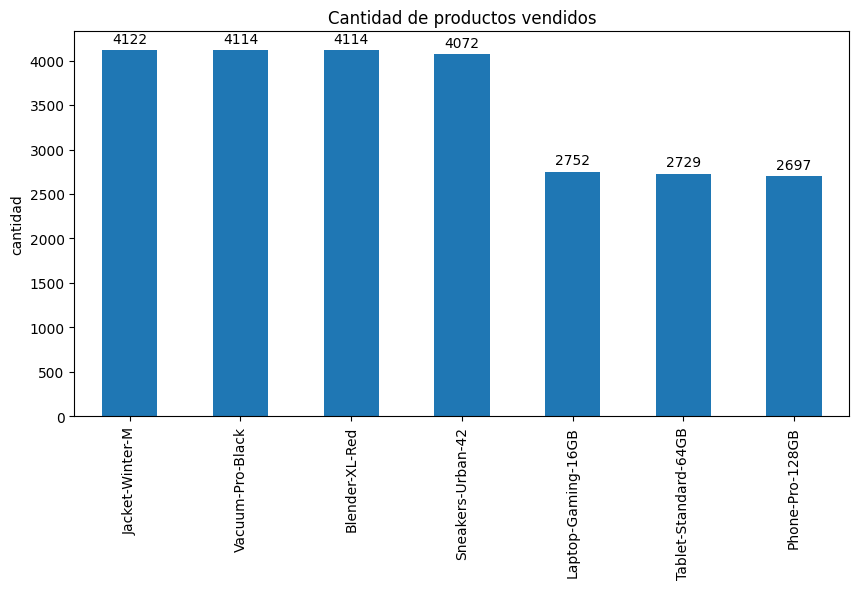

In [55]:

ax = merged_left['nombre_producto'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Cantidad de productos vendidos')
plt.ylabel('cantidad')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.show()

In [56]:
#¿Cuánto se ha gastado en marketing por canal?
marketing['canal'].value_counts()

paid_search    608
organic        506
social         506
Name: canal, dtype: int64

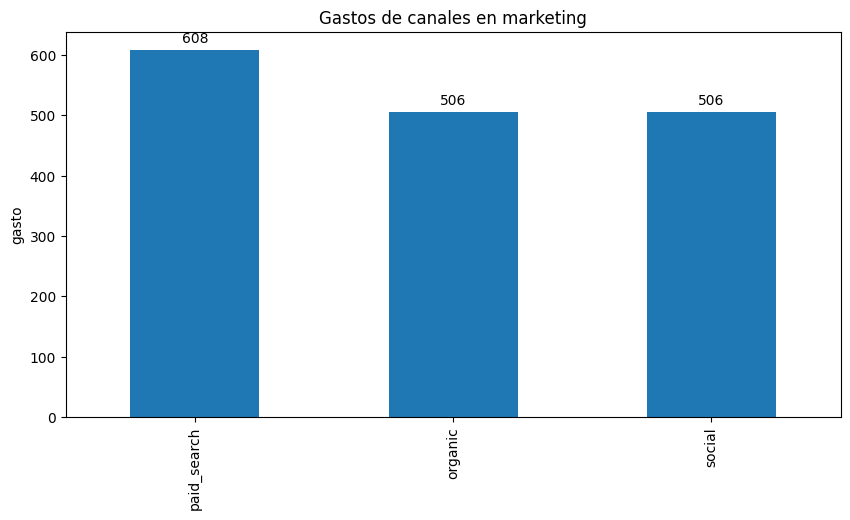

In [57]:

ax = marketing['canal'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Gastos de canales en marketing')
plt.ylabel('gasto')
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points'
    )
plt.show()

Parte 2: Comportamiento de ventas

-El ticket promedio se calculo dividiendo los ingresos totales entre el numero total de pedidos, el cual dio como resultado $2,107.17

-La cantidad promedio de productos por orden se obtuvo sumando las cantidades vendidas y el resultado se dividio entre el total de pedidos el cual dio como resultado 7.2

-El producto mas vendido es el de Jacket-Winter-M con 4122 cantidades. Se adjunto un grafico de barras mostrando las cantidades vendidas por producto.

-Los gastos de marketing por canal son de 'paid_search' $608,
'organic' $506,
'social' $506. Se adjunto un grafico de barras mostrando los gastos para cada canal de marketing.

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [58]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [59]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [60]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   id_usuario          120000 non-null  object
 1   id_sesion           120000 non-null  object
 2   nombre_evento       120000 non-null  object
 3   timestamp_evento    120000 non-null  object
 4   pais                120000 non-null  object
 5   dispositivo         120000 non-null  object
 6   fuente_referencia   120000 non-null  object
 7   categoria_producto  120000 non-null  object
dtypes: object(8)
memory usage: 7.3+ MB


In [61]:
events['timestamp_evento']=pd.to_datetime(events['timestamp_evento'], errors="coerce")
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id_usuario          120000 non-null  object        
 1   id_sesion           120000 non-null  object        
 2   nombre_evento       120000 non-null  object        
 3   timestamp_evento    120000 non-null  datetime64[ns]
 4   pais                120000 non-null  object        
 5   dispositivo         120000 non-null  object        
 6   fuente_referencia   120000 non-null  object        
 7   categoria_producto  120000 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 7.3+ MB


In [62]:
events['timestamp_evento'].min()		

Timestamp('2025-01-01 00:00:00')

In [63]:
events['timestamp_evento'].max()

Timestamp('2025-06-30 00:00:00')

In [64]:
events['nombre_evento'].unique()

array(['first_visit', 'add_to_cart', 'add_payment_info', 'purchase',
       'begin_checkout', 'select_item'], dtype=object)

In [65]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''


WITH first_visit AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'first_visit'AND timestamp_evento BETWEEN '2025-01-01' AND '2025-06-30'
    ),
add_to_cart AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_to_cart'AND timestamp_evento BETWEEN '2025-01-01' AND '2025-06-30'
),
select_item AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'select_item'AND timestamp_evento BETWEEN '2025-01-01' AND '2025-06-30'
),
begin_checkout AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'begin_checkout'AND timestamp_evento BETWEEN '2025-01-01' AND '2025-06-30'
),
add_payment_info AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_payment_info'AND timestamp_evento BETWEEN '2025-01-01' AND '2025-06-30'
),
purchase AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'purchase'AND timestamp_evento BETWEEN '2025-01-01' AND '2025-06-30'
)


SELECT 
    COUNT (fv.id_usuario) AS usuarios_first_visit,
    COUNT (atc.id_usuario) AS usuarios_add_to_cart,
    COUNT (si.id_usuario) AS usuarios_select_item,
    COUNT (bc.id_usuario) AS usuarios_begin_checkout,
    COUNT (api.id_usuario) AS usuarios_add_payment_info,
    COUNT (p.id_usuario) AS usuarios_purchase
FROM first_visit AS fv
LEFT JOIN add_to_cart AS atc ON fv.id_usuario = atc.id_usuario
LEFT JOIN select_item AS si ON fv.id_usuario = si.id_usuario
LEFT JOIN begin_checkout AS bc ON fv.id_usuario = bc.id_usuario
LEFT JOIN add_payment_info AS api ON fv.id_usuario =api.id_usuario
LEFT JOIN purchase AS p ON fv.id_usuario = p.id_usuario


'''

totals = pd.read_sql(query_totals, con=engine)
totals

,usuarios_first_visit,usuarios_add_to_cart,usuarios_select_item,usuarios_begin_checkout,usuarios_add_payment_info,usuarios_purchase
0,7796,7439,7393,7031,6088,6068


In [66]:
events[events['nombre_evento']=='first_visit']['id_usuario'].nunique()

7796

In [67]:
events['nombre_evento'].unique()

array(['first_visit', 'add_to_cart', 'add_payment_info', 'purchase',
       'begin_checkout', 'select_item'], dtype=object)

In [68]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH first_visit AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'first_visit'AND timestamp_evento BETWEEN '2025-01-01' AND '2025-06-30'
    ),
add_to_cart AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_to_cart'AND timestamp_evento BETWEEN '2025-01-01' AND '2025-06-30'
),
select_item AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'select_item'AND timestamp_evento BETWEEN '2025-01-01' AND '2025-06-30'
),
begin_checkout AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'begin_checkout'AND timestamp_evento BETWEEN '2025-01-01' AND '2025-06-30'
),
add_payment_info AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_payment_info'AND timestamp_evento BETWEEN '2025-01-01' AND '2025-06-30'
),
purchase AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'purchase'AND timestamp_evento BETWEEN '2025-01-01' AND '2025-06-30'
),
funnel_conversion AS(
SELECT 
    COUNT (fv.id_usuario) AS usuarios_first_visit,
    COUNT (atc.id_usuario) AS usuarios_add_to_cart,
    COUNT (si.id_usuario) AS usuarios_select_item,
    COUNT (bc.id_usuario) AS usuarios_begin_checkout,
    COUNT (api.id_usuario) AS usuarios_add_payment_info,
    COUNT (p.id_usuario) AS usuarios_purchase
FROM first_visit AS fv
LEFT JOIN add_to_cart AS atc ON fv.id_usuario = atc.id_usuario
LEFT JOIN select_item AS si ON fv.id_usuario = si.id_usuario
LEFT JOIN begin_checkout AS bc ON fv.id_usuario = bc.id_usuario
LEFT JOIN add_payment_info AS api ON fv.id_usuario =api.id_usuario
LEFT JOIN purchase AS p ON fv.id_usuario = p.id_usuario
)
SELECT
  ROUND (usuarios_add_to_cart *100.0/usuarios_first_visit,2) AS conversion_add_to_cart,
   ROUND (usuarios_select_item * 100.0/ usuarios_first_visit,2) AS conversion_select_item,
    ROUND (usuarios_begin_checkout *100.0/ usuarios_first_visit,2) AS conversion_begin_checkout,
    ROUND (usuarios_add_payment_info *100.0/ usuarios_first_visit,2) AS conversion_add_payment_info,
    ROUND (usuarios_purchase *100.0/ usuarios_first_visit,2) AS conversion_purchase
FROM funnel_conversion 
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,conversion_add_to_cart,conversion_select_item,conversion_begin_checkout,conversion_add_payment_info,conversion_purchase
0,95.42,94.83,90.19,78.09,77.83


Se observa que en el embudo las etapas de  agregar al carrito y selccionar producto estan invertidos conforme a datos. Deberia de ser primero seleccionar productos y despues agregar al carrito, para que los datos del embudo tengan sentido se acomodo primero agregar al carrito y despues seleccionar productos.

Se observa en el embudo que la etapa donde se pierde la mayoria de los usuarios es en 'agregar la informacion de pago'

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [69]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [70]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [71]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohort AS(
SELECT 
    id_usuario,
    DATE_TRUNC('month',CAST(fecha_registro AS DATE)) AS cohort
FROM users
),
activity AS (
SELECT
    ua.id_usuario,
    (dias_despues_registro/7) AS registro_semanas,
    ua.activo
    FROM user_activity AS ua
),
base AS (
SELECT
    c.cohort,
    c.id_usuario,
    ac.registro_semanas,
    ac.activo
FROM cohort as c
LEFT JOIN activity AS ac 
 ON c.id_usuario = ac.id_usuario
)
SELECT
    cohort,
    COUNT (DISTINCT id_usuario) AS clientes_iniciales,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN registro_semanas >= 1 AND activo = 1 THEN id_usuario END) / NULLIF(COUNT(DISTINCT id_usuario),0),1) AS retention_s1_pct,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN registro_semanas >= 2 AND activo = 1 THEN id_usuario END) / NULLIF(COUNT(DISTINCT id_usuario),0),1) AS retention_s2_pct,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN registro_semanas >= 3 AND activo = 1 THEN id_usuario END) / NULLIF(COUNT(DISTINCT id_usuario),0),1) AS retention_s3_pct
FROM base 
GROUP BY cohort
ORDER BY cohort;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohort,clientes_iniciales,retention_s1_pct,retention_s2_pct,retention_s3_pct
0,2025-01-01 00:00:00+00:00,1627,84.9,77.0,63.1
1,2025-02-01 00:00:00+00:00,1444,86.9,79.9,65.1
2,2025-03-01 00:00:00+00:00,1636,87.3,79.8,64.8
3,2025-04-01 00:00:00+00:00,1606,86.8,78.5,63.6
4,2025-05-01 00:00:00+00:00,1687,85.7,78.3,64.5


---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** ...La tasa de conversion es igual.
   - **H₁ (Hipótesis alternativa):** ...La modificacion mejora la tasa de conversion
   
**Test estadístico:** ...  Prueba Chi2 para variables categoricas

**Nivel de significancia alpha:** ...0.05

In [72]:
# tu código aquí
from scipy.stats import chi2_contingency

experimento = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')
experimento['timestamp'] = pd.to_datetime(experimento['timestamp'], errors='coerce')
experimento.head()

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [73]:
tabla_variente = pd.crosstab(experimento['variante'],experimento['convirtio'])
tabla_variente

convirtio,0,1
variante,,
control,4186,779
tratamiento,4215,820


In [74]:
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_variente)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 0.618
Valor P: 0.432
Grados de libertad: 1

Frecuencias esperadas:
[[4171.0965  793.9035]
 [4229.9035  805.0965]]


Resultado del experimento:
P_value es alto comparado al umbral alpha (0.05) por lo tanto no rechazamos la hipótesis nula.

Interpretación de negocio:
Esto sugiere que el hecho de que un usuario pertenesca a la variante contro o tratamiento no es un factor determinante para su probabilidad de convertir en este conjunto de datos específico. No podemos afirmar que la modificacion realizada en el checkout convierta mejor que el que no esta modificado, basándonos en estos datos.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

# link de one drive / google drive
https://drive.google.com/drive/folders/1Tsy7LDhOFS8-FKcxKxGY7OS25HH2IIJV?usp=drive_link